<a href="https://colab.research.google.com/github/essanchristian-maker/DI-Bootcamp/blob/master/Week2_Day2_challenge.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import zipfile
import requests
import io
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.decomposition import PCA

def load_csv_from_zip_url(url):
    response = requests.get(url)
    z = zipfile.ZipFile(io.BytesIO(response.content))
    csv_name = [f for f in z.namelist() if f.endswith(".csv")][0]
    return pd.read_csv(z.open(csv_name), encoding="latin-1")

url_salary = "https://github.com/devtlv/Datasets-DA-Bootcamp-2-/raw/refs/heads/main/Week%204%20-%20Data%20Understanding/W4D4%20-%20Data%20Preprocessing%20&%20T/Data%20Science%20Job%20Salary%20dataset.zip"

salary_df = load_csv_from_zip_url(url_salary)

print(salary_df.columns.tolist())
print(salary_df.shape)
salary_df.head()

['Unnamed: 0', 'job_title', 'job_type', 'experience_level', 'location', 'salary_currency', 'salary']
(1171, 7)


,Unnamed: 0,job_title,job_type,experience_level,location,salary_currency,salary
0,0,Data scientist,Full Time,Senior,New York City,USD,149000
1,2,Data scientist,Full Time,Senior,Boston,USD,120000
2,3,Data scientist,Full Time,Senior,London,USD,68000
3,4,Data scientist,Full Time,Senior,Boston,USD,120000
4,5,Data scientist,Full Time,Senior,New York City,USD,149000


In [2]:
scaler_mm = MinMaxScaler()
salary_df["salary_normalized"] = scaler_mm.fit_transform(salary_df[["salary"]])

print(salary_df[["salary", "salary_normalized"]].head())
print("\nSalary_normalized stats :")
print(salary_df["salary_normalized"].describe().round(3))

   salary  salary_normalized
0  149000           0.601010
1  120000           0.454545
2   68000           0.191919
3  120000           0.454545
4  149000           0.601010

Salary_normalized stats :
count    1171.000
mean        0.176
std         0.164
min         0.000
25%         0.076
50%         0.167
75%         0.192
max         1.000
Name: salary_normalized, dtype: float64


Explained variance ratio : [0.342 0.248]
Total variance explained  : 0.59


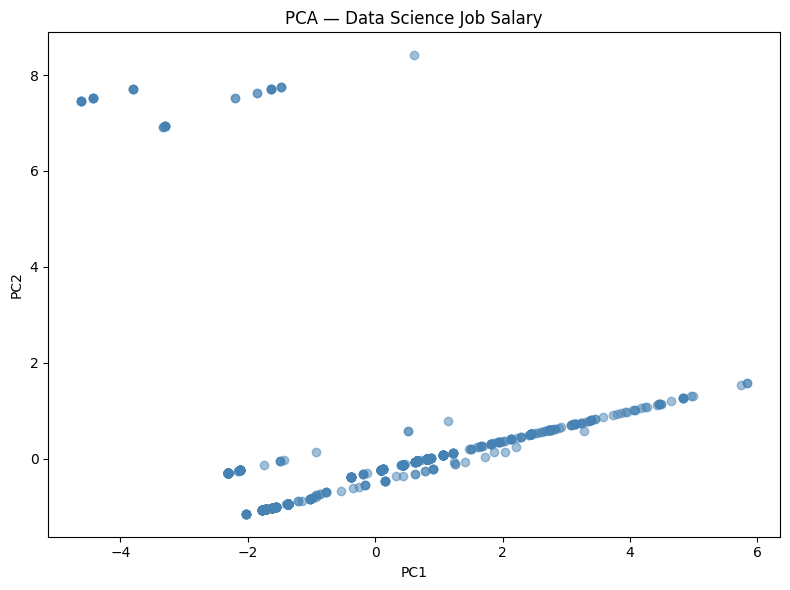

In [3]:
# Select numerical columns
num_cols = ["salary", "salary_normalized"]

# Add encoded categorical columns for PCA
salary_encoded = pd.get_dummies(salary_df[["job_type", "experience_level"]])

# Combine
X = pd.concat([salary_df[num_cols], salary_encoded], axis=1)

# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("Explained variance ratio :", pca.explained_variance_ratio_.round(3))
print("Total variance explained  :", pca.explained_variance_ratio_.sum().round(3))

# Visualize
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.5, color="steelblue")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA — Data Science Job Salary")
plt.tight_layout()
plt.show()

In [4]:
agg_salary = salary_df.groupby("experience_level")["salary"].agg(
    Average="mean",
    Median="median"
).round(2)

print(agg_salary)

                   Average   Median
experience_level                   
Entry             36111.11  30000.0
Executive         76076.92  46000.0
Mid               51786.89  51000.0
Senior            75088.03  68000.0


### Step 1 : Min-Max Normalization on Salary
- Salary range normalized to [0, 1].
- Mean normalized salary : 0.176
- Most salaries are concentrated in the lower range
  (75% below 0.192), with a few high outliers reaching 1.0.

### Step 2 : PCA — Dimensionality Reduction
| Component | Variance Explained |
|---|---|
| PC1 | 34.2% |
| PC2 | 24.8% |
| Total | 59.0% |

2 components capture 59% of total variance.
The PCA plot shows two distinct clusters — likely
corresponding to different experience levels or job types.

### Step 3 : Salary Aggregation by Experience Level
| Experience Level | Average Salary | Median Salary |
|---|---|---|
| Entry | $36,111 | $30,000 |
| Mid | $51,786 | $51,000 |
| Senior | $75,088 | $68,000 |
| Executive | $76,076 | $46,000 |

### Key Insights
- Salary increases consistently with experience level.
- Entry level average ($36K) is less than half of
  Senior level ($75K).
- Executive median ($46K) is lower than its average ($76K)
  — suggesting a few very high salaries pulling the mean up.
- Mid and Senior levels show the most consistent salaries
  (mean and median are close).